[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/raulpg14/Quantum-Internet-Network-Simulator/blob/master/notebooks/02_evolution_analysis.ipynb)

# Network evolution analysis — average path length and diameter
Analyses how average shortest path length and diameter scale with number of nodes N at fixed density.
Compatible with local Jupyter and Google Colab.

In [17]:
import sys
try:
    import qcn
except ImportError:
    import subprocess
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet',
        'git+https://github.com/raulpg14/Quantum-Internet-Network-Simulator.git'
    ])
    import qcn

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from qcn.engine.simulation import run_simulation
from qcn.engine.config import (
    NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI,
    SIM_MODE_EVOLUTION, STYLE_MAP,
    DEFAULT_DENSITY_COEFF_EVOLUTION,
)
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [19]:
# --- Simulation parameters ---
# Use smaller values for CI/testing, increase for real analysis
import os
IN_CI = os.environ.get("CI", False)

INITIAL_NODES = 100 #if IN_CI else 500
DENSITY_COEFF = DEFAULT_DENSITY_COEFF_EVOLUTION
MC_REPS = 1 #if IN_CI else 5
STEPS = 3 #if IN_CI else 8
NODE_INCREMENT = 50 #if IN_CI else 200
SEED = 42
# -----------------------------

In [20]:
results = {}
for net_type in [NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI]:
    res = run_simulation({
        'nodes': INITIAL_NODES,
        'radius': DENSITY_COEFF,
        'type': net_type,
        'mc_iter': MC_REPS,
        'nets_per_mc': STEPS,
        'rad_incr': NODE_INCREMENT,
        'sim_mode': SIM_MODE_EVOLUTION,
        'seed': SEED,
    })
    if res.get('success'):
        results[net_type] = res
        print(f"{net_type}: OK")
    else:
        print(f"{net_type}: ERROR — {res.get('error')}")

OFBQI: OK
SBQI: OK


In [21]:
import time
from qcn.engine.results_store import save_run, get_runs

# Save results to the database
for net_type, res in results.items():
    run_id = save_run(res, duration_s=0.0)
    print(f"{net_type}: saved as run_id={run_id}")

# Show all runs in the database
runs = get_runs()
print(f"\nTotal runs in database: {len(runs)}")

KeyError: 'a'

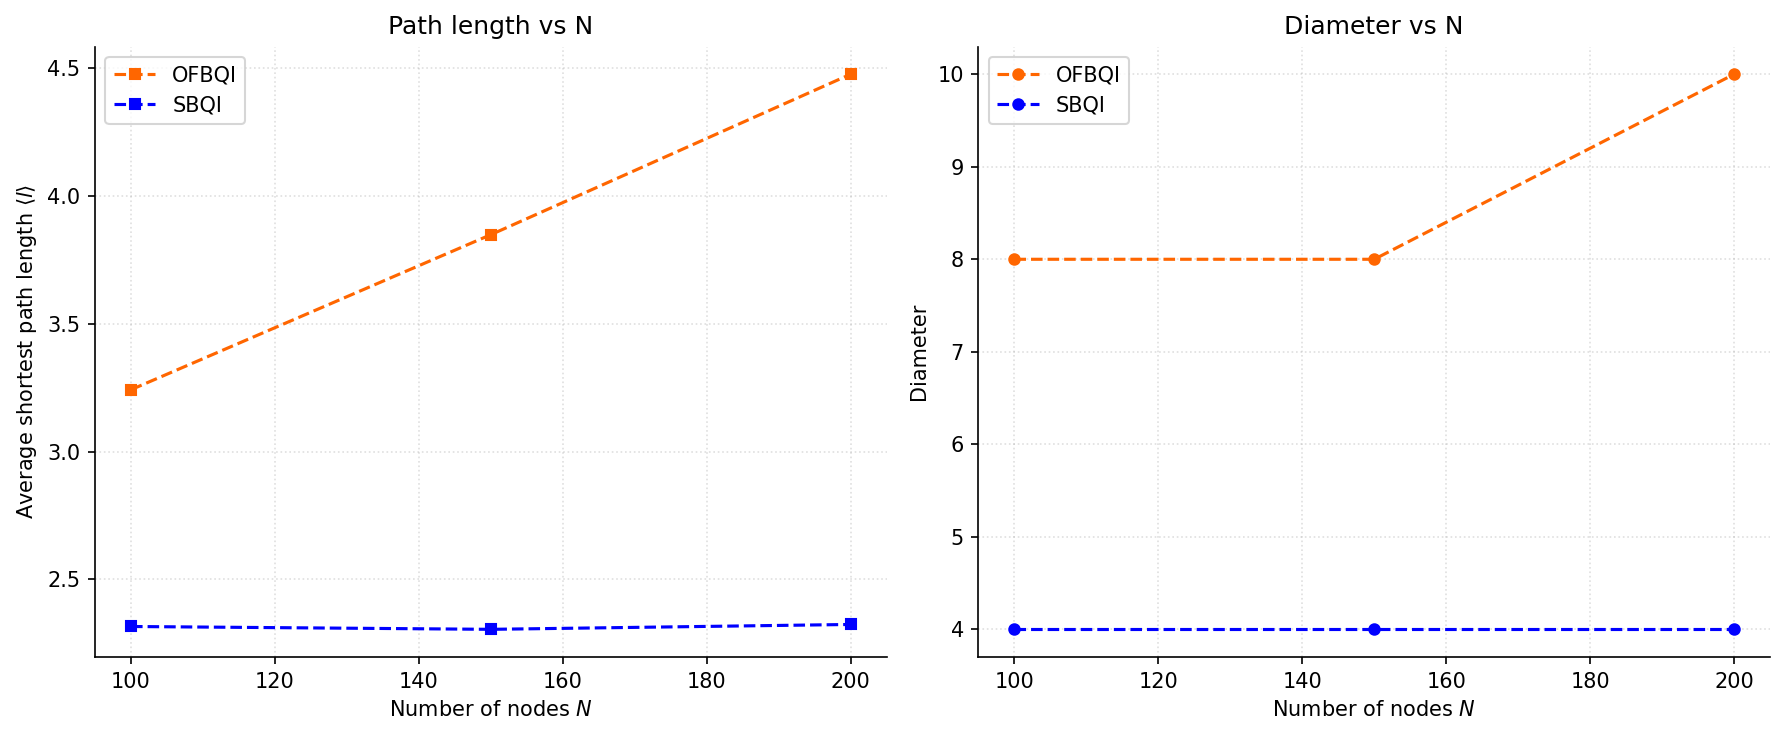

Figure saved to evolution_analysis.pdf


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for net_type, res in results.items():
    style = STYLE_MAP[net_type]
    ax1.plot(res['x_nodes'], res['y_path'],
             color=style['color'], marker='s', linestyle='--',
             markersize=5, label=style['label'])
    ax2.plot(res['x_nodes'], res['y_diameter'],
             color=style['color'], marker='o', linestyle='--',
             markersize=5, label=style['label'])
ax1.set_xlabel('Number of nodes $N$')
ax1.set_ylabel('Average shortest path length $\\langle l \\rangle$')
ax1.set_title('Path length vs N')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.4)
ax2.set_xlabel('Number of nodes $N$')
ax2.set_ylabel('Diameter')
ax2.set_title('Diameter vs N')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()
print('Figure saved to evolution_analysis.pdf')

In [15]:
import numpy as np
from qcn.engine.math_util import log_func, power_func

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for net_type, res in results.items():
    style   = STYLE_MAP[net_type]
    x_nodes = np.array(res['x_nodes'])
    y_path  = np.array(res['y_path'])
    y_diam  = np.array(res['y_diameter'])
    fp      = res.get('fit_params')

    # Simulation points
    ax1.plot(x_nodes, y_path,
             color=style['color'], marker='s', linestyle='',
             markersize=5, alpha=0.8, label=style['label'])
    ax2.plot(x_nodes, y_diam,
             color=style['color'], marker='o', linestyle='',
             markersize=5, alpha=0.8, label=style['label'])

    # Fit curve overlaid
    if fp:
        x_fit = np.linspace(x_nodes.min(), x_nodes.max(), 300)
        fit_type = fp.get('type')
        if fit_type == 'logarithmic':
            y_fit = log_func(x_fit, fp['a'], fp['b'])
            fit_label = rf"ln fit: {fp['formula']}"
        elif fit_type == 'powerlaw':
            y_fit = power_func(x_fit, fp['b'], fp['alpha'])
            fit_label = rf"power law: {fp['formula']}"
        else:
            y_fit = None

        if y_fit is not None:
            ax1.plot(x_fit, y_fit,
                     color=style['color'], linestyle='--',
                     linewidth=1.5, alpha=0.9, label=fit_label)

ax1.set_xlabel('Number of nodes $N$')
ax1.set_ylabel('Average shortest path length $\\langle l \\rangle$')
ax1.set_title('Path length vs $N$')
ax1.legend(fontsize=7)
ax1.grid(True, linestyle=':', alpha=0.4)

ax2.set_xlabel('Number of nodes $N$')
ax2.set_ylabel('Diameter $d$')
ax2.set_title('Diameter vs $N$')
ax2.legend(fontsize=7)
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


ImportError: cannot import name 'log_func' from 'qcn.engine.math_util' (C:\Users\ragap\Documents\GitHub\NetworkCreator Tool\qcn\engine\math_util.py)

In [14]:
for net_type, res in results.items():
    fp = res.get('fit_params')
    if fp:
        fit_type = fp.get('type', 'unknown')
        print(f"{net_type} ({fit_type}): {fp['formula']}")
    else:
        print(f"{net_type}: fit not available")

OFBQI (powerlaw): l = 0.373432 * N^0.4678
SBQI (logarithmic): l = 0.0089 * ln(N) + 2.2705
